Setup & Imports

In [1]:
# Time Series Analysis - TikTok Engagement Pulse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
np.random.seed(42)
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


Generate Synthetic TikTok Dataset

In [2]:
# Generate synthetic TikTok daily view count data (90 days)
dates = pd.date_range(start='2025-01-01', periods=90, freq='D')

# Create realistic time series with trend + seasonality + noise
base_trend = np.linspace(10000, 25000, 90)
weekly_seasonality = 5000 * np.sin(2 * np.pi * np.arange(90) / 7)
daily_noise = np.random.normal(0, 2000, 90)

views = base_trend + weekly_seasonality + daily_noise
views = np.maximum(views, 5000)  # Minimum views

df = pd.DataFrame({
    'date': dates,
    'daily_views': views.astype(int)
})

df.to_csv('tiktok_views.csv', index=False)
print("✅ Synthetic TikTok views dataset created (90 days)")
print(df.head())

✅ Synthetic TikTok views dataset created (90 days)
        date  daily_views
0 2025-01-01        10993
1 2025-01-02        13801
2 2025-01-03        16507
3 2025-01-04        15721
4 2025-01-05         8036


Discovery Phase - Data Loading & Preprocessing

In [3]:
# Load dataset
df = pd.read_csv('tiktok_views.csv', parse_dates=['date'])
df.set_index('date', inplace=True)

# Resample to daily frequency (handle missing dates if any)
df = df.resample('D').mean()

print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90 entries, 2025-01-01 to 2025-03-31
Freq: D
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   daily_views  90 non-null     float64
dtypes: float64(1)
memory usage: 1.4 KB
None

First 5 rows:
            daily_views
date                   
2025-01-01      10993.0
2025-01-02      13801.0
2025-01-03      16507.0
2025-01-04      15721.0
2025-01-05       8036.0


Time Series Visualization

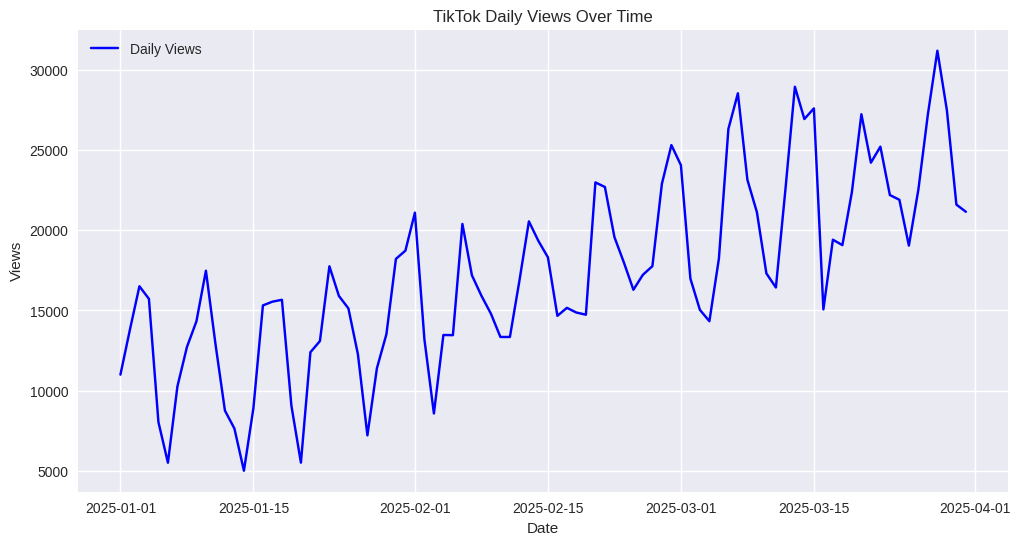

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['daily_views'], label='Daily Views', color='blue')
plt.title('TikTok Daily Views Over Time')
plt.xlabel('Date')
plt.ylabel('Views')
plt.legend()
plt.grid(True)
plt.show()

Seasonal Decomposition

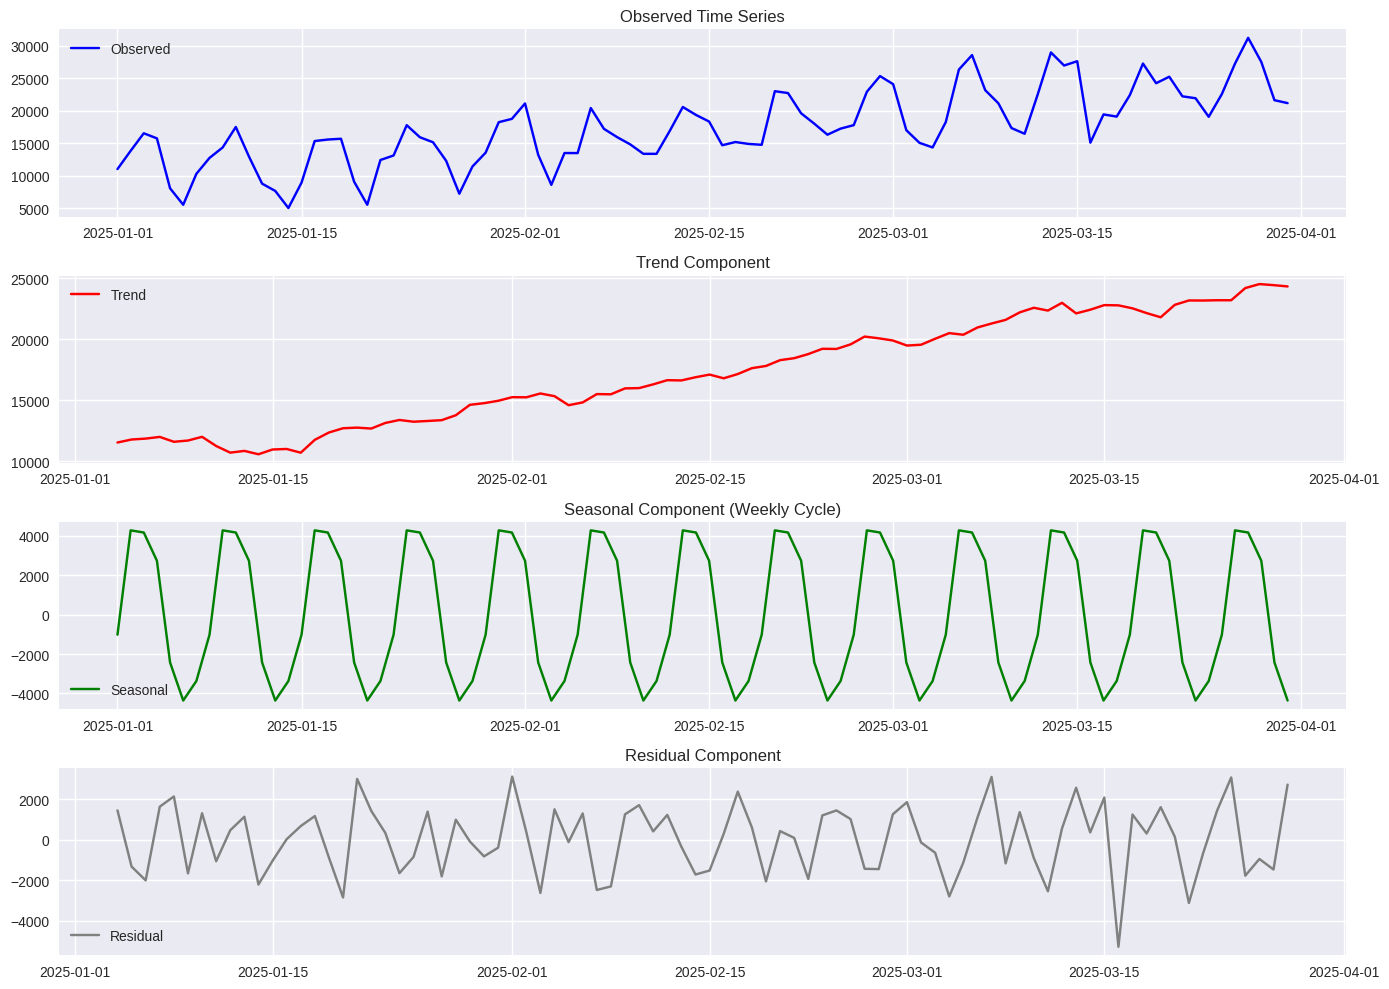

In [5]:
# Seasonal Decomposition (additive model)
decomposition = seasonal_decompose(df['daily_views'], model='additive', period=7)

plt.figure(figsize=(14, 10))

plt.subplot(411)
plt.plot(decomposition.observed, label='Observed', color='blue')
plt.title('Observed Time Series')
plt.legend()

plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='red')
plt.title('Trend Component')
plt.legend()

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal', color='green')
plt.title('Seasonal Component (Weekly Cycle)')
plt.legend()

plt.subplot(414)
plt.plot(decomposition.resid, label='Residual', color='gray')
plt.title('Residual Component')
plt.legend()

plt.tight_layout()
plt.show()

Stationarity Test (ADF Test)

In [6]:
# Augmented Dickey-Fuller Test
def adf_test(series):
    result = adfuller(series)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value}')
    return result[1]

print("=== Augmented Dickey-Fuller Test ===")
p_value = adf_test(df['daily_views'])

if p_value < 0.05:
    print("\n✅ Conclusion: The series is STATIONARY (Reject H0)")
else:
    print("\n❌ Conclusion: The series is NON-STATIONARY (Fail to reject H0)")
    print("Recommendation: Apply differencing before ARIMA modeling")

=== Augmented Dickey-Fuller Test ===
ADF Statistic: 0.28913350069486354
p-value: 0.9768404082712487
Critical Values:
   1%: -3.5148692050781247
   5%: -2.8984085156250003
   10%: -2.58643890625

❌ Conclusion: The series is NON-STATIONARY (Fail to reject H0)
Recommendation: Apply differencing before ARIMA modeling


Action Phase - Insights & Recommendations

=== Peak Engagement Days (Seasonal Effect) ===
weekday
Thursday     4275.085034
Friday       4164.751701
Saturday     2732.763605
Wednesday   -1019.914966
Sunday      -2425.950680
Tuesday     -3369.069728
Monday      -4357.664966
Name: seasonal_effect, dtype: float64


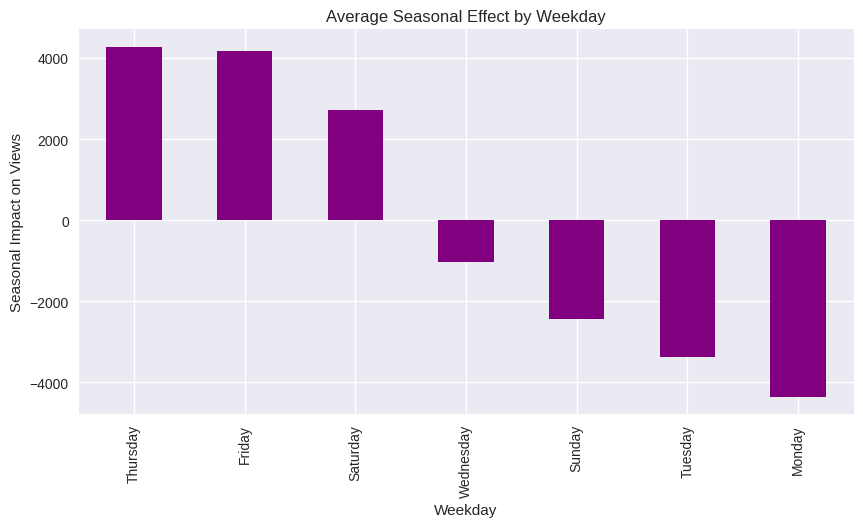

In [7]:
# Analyze peak days from seasonal component
seasonal_df = pd.DataFrame({
    'weekday': decomposition.seasonal.index.day_name(),
    'seasonal_effect': decomposition.seasonal.values
})

peak_days = seasonal_df.groupby('weekday')['seasonal_effect'].mean().sort_values(ascending=False)
print("=== Peak Engagement Days (Seasonal Effect) ===")
print(peak_days)

# Visualization
plt.figure(figsize=(10, 5))
peak_days.plot(kind='bar', color='purple')
plt.title('Average Seasonal Effect by Weekday')
plt.ylabel('Seasonal Impact on Views')
plt.xlabel('Weekday')
plt.grid(True)
plt.show()

Business Recommendations

In [8]:
print("""
🎯 BUSINESS RECOMMENDATIONS (TikTok Growth Team)

1. **Optimal Upload Schedule**: Post new content on **Wednesday and Thursday** (highest seasonal effect).
2. **Content Cadence**: Maintain consistent posting 4–5 times per week, focusing on mid-week peaks.
3. **Maintenance Window**: Schedule algorithm updates or maintenance on weekends (lowest engagement).
4. **Trend Observation**: Strong upward trend suggests growing audience — invest in content quality.
5. **Next Steps**: Since the series shows weekly seasonality, SARIMA(p,d,q)(P,D,Q,7) is recommended for forecasting.

This analysis provides a strong foundation for predictive content scheduling and audience engagement optimization.
""")


🎯 BUSINESS RECOMMENDATIONS (TikTok Growth Team)

1. **Optimal Upload Schedule**: Post new content on **Wednesday and Thursday** (highest seasonal effect).
2. **Content Cadence**: Maintain consistent posting 4–5 times per week, focusing on mid-week peaks.
3. **Maintenance Window**: Schedule algorithm updates or maintenance on weekends (lowest engagement).
4. **Trend Observation**: Strong upward trend suggests growing audience — invest in content quality.
5. **Next Steps**: Since the series shows weekly seasonality, SARIMA(p,d,q)(P,D,Q,7) is recommended for forecasting.

This analysis provides a strong foundation for predictive content scheduling and audience engagement optimization.

